# Valid Samples Metrics Analysis

This notebook explores statistical properties of the extracted dataset filtered to only include valid samples.
Valid samples are defined as those that:

- Belong to one of the following languages: Python, Java, or C++
- Have a label of either MACHINE_GENERATED or HUMAN_GENERATED
- Are successfully parsed by TranStructiver without any ERROR nodes in the resulting parse tree

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/valid_samples/valid_samples.parquet")

In [13]:
# ----------------------------
# BASIC INFO
# ----------------------------
print("=== DATASET OVERVIEW ===")
print(f"Total samples: {len(df)}\n")

print("=== LANGUAGE DISTRIBUTION ===")
print(df["language"].value_counts(), "\n")

print("=== LABEL DISTRIBUTION ===")
print(df["label"].value_counts(), "\n")

print("=== LANGUAGE × LABEL DISTRIBUTION ===")
print(df.groupby(["language", "label"]).size())

=== DATASET OVERVIEW ===
Total samples: 498845

=== LANGUAGE DISTRIBUTION ===
language
Python    242528
Java      181079
C++        75238
Name: count, dtype: int64 

=== LABEL DISTRIBUTION ===
label
HUMAN_GENERATED      308762
MACHINE_GENERATED    190083
Name: count, dtype: int64 

=== LANGUAGE × LABEL DISTRIBUTION ===
language  label            
C++       HUMAN_GENERATED       32820
          MACHINE_GENERATED     42418
Java      HUMAN_GENERATED      130879
          MACHINE_GENERATED     50200
Python    HUMAN_GENERATED      145063
          MACHINE_GENERATED     97465
dtype: int64


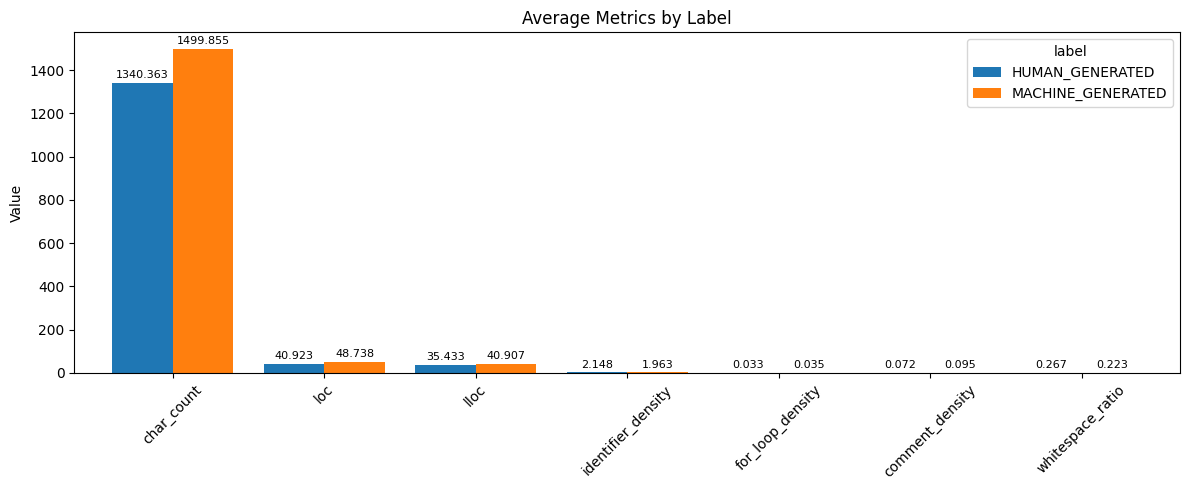

In [15]:
metrics = [
    "char_count",
    "loc",
    "lloc",
    "identifier_density",
    "for_loop_density",
    "comment_density",
    "whitespace_ratio",
]

label_means = df.groupby("label")[metrics].mean().T  # transpose so metrics are x-axis

ax = label_means.plot(
    kind="bar",
    figsize=(12, 5),
    width=0.8  # 👉 controls spacing between label bars
)

plt.title("Average Metrics by Label")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.legend(title="label")

# add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)

plt.tight_layout()
plt.show()

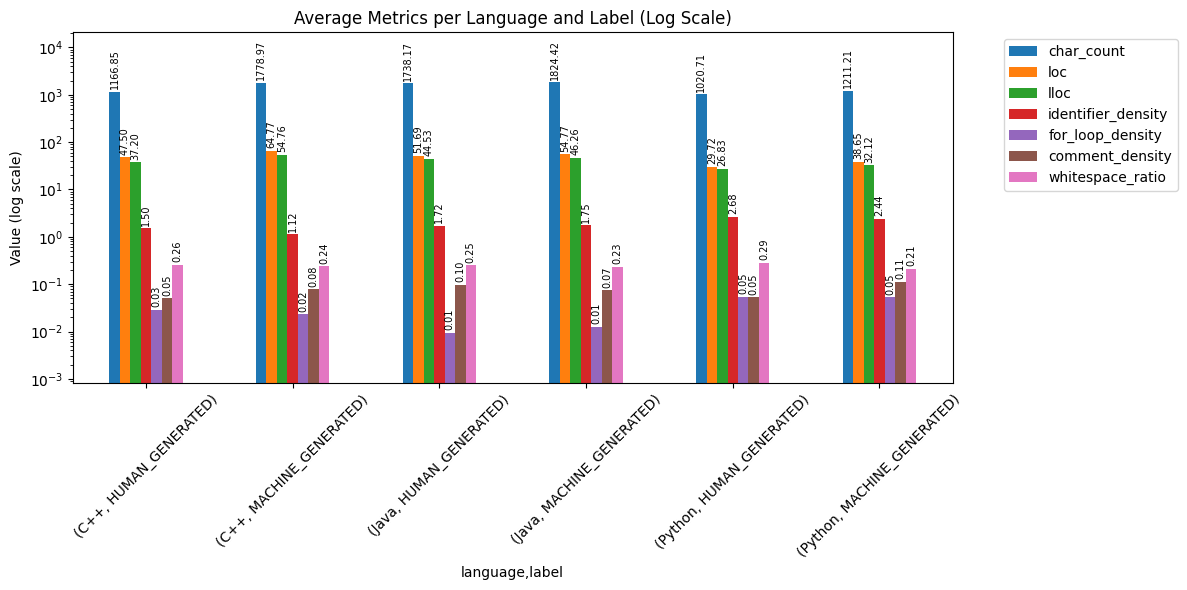

In [12]:
lang_means = df.groupby("language")[metrics].mean()

lang_label_means = df.groupby(["language", "label"])[metrics].mean()

ax = lang_label_means.plot(kind="bar", figsize=(12, 6))

plt.yscale("log")
plt.title("Average Metrics per Language and Label (Log Scale)")
plt.ylabel("Value (log scale)")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

ax.margins(y=0.2)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=7, rotation=90, padding=2)

plt.tight_layout()
plt.show()